## Transport Analysis from the Onsager Framework
-------
Code by Madeline Murphy, adapted from code from Kara Fong

In [15]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import MDAnalysis as mda
import importlib
import glob 
import gc
import os

import warnings
warnings.filterwarnings("ignore")

import transport_analysis_orig as ta
importlib.reload(ta)


<module 'transport_analysis_orig' from '/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/analysis/transport-analysis/transport_analysis_orig.py'>

In [16]:
colors = plt.get_cmap('Dark2')(range(6))

In [17]:
def create_mda(path, data_file, dcd_file, cat_dcd=False):
    if cat_dcd:  
        all_dcd_files = glob.glob(path + dcd_file)
        step = []
        for f in all_dcd_files:
            step.append(int(f.replace('.','_').split('_')[-2]))
        dcd_file = [x for _,x in sorted(zip(step,all_dcd_files))]
        # print(dcd_file)
    else:
        dcd_file = path + dcd_file
    run = mda.Universe(path + data_file,dcd_file, format="LAMMPS", atom_style='id resid type x y z')
    
    atom_names = {'1': 'O',
              '2': 'H',
              '3': 'C',
              '4': 'N_NO',
              '5': 'O_NO'}

    names = []
    for atom in run.atoms:
        names.append(atom_names[atom.type])
    run.add_TopologyAttr('name', names)
    
    return run

-----
### Analysis Functions

In [22]:
def analyze_conductivity_orig(runs, base_dir, cation, conc, start, end, run_start, samplingperiod, T, rerun=False):

        cond_msds = np.empty((len(runs)), dtype=object)
        times_all = np.empty((len(runs)), dtype=object)
        cond_all = np.empty((len(runs)), dtype=float)
        beta_all = np.empty((len(runs)), dtype=float) 

        folder = f'{base_dir}simulations/{cation}/{conc}/'

        for j, r in enumerate(runs):
                path = os.path.join(folder, f"rep{r}/")
                print(path)
                u = create_mda(
                        path,
                        data_file="system.data",
                        dcd_file="nvt_unwrapped_*.dcd",
                        cat_dcd=True,
                        )

                path = os.path.join(base_dir, f"data/{cation}/{conc}/rep{r}")

                if path is not None:
                        Path(path).mkdir(parents=True, exist_ok=True)

                msd, msd_var, times = ta.get_cond_msd(path, u, run_start, samplingperiod, dirs='xyz', T=T, rerun=rerun)

                cond_msds[j] = msd
                times_all[j] = times
                cond_all[j], _ = ta.fit_data(msd, times, start, end, weighted=True, msd_var=msd_var)
                _, beta_all[j] = ta.fit_data(msd, times, start, end, weighted=False)
                del u
                gc.collect()

        ta.make_one_msd_plot(times_all[0], cond_msds[0], start, end)

        return cond_msds, times_all, cond_all, beta_all

In [30]:
def onsager_transport_orig(runs, base_dir, cation, conc, start, end, run_start, samplingperiod, T, rerun=False):

    lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']
    lij_msds = np.empty((len(lij_names), len(runs)), dtype=object)
    lij_all = np.empty((len(lij_names), len(runs)), dtype=float)
    lij_beta_all = np.empty((len(lij_names), len(runs)), dtype=float) 

    folder = f'{base_dir}simulations/{cation}/{conc}/'

    for j, r in enumerate(runs):
        path = os.path.join(folder, f"rep{r}/")
        print(path) 
        u = create_mda(
                path,
                data_file="system.data",
                dcd_file="nvt_unwrapped_*.dcd",
                cat_dcd=True,)
        
        # define new folder to store transport data
        path = os.path.join(base_dir, f"data/{cation}/{conc}/rep{r}")
        msds, msd_vars, times = ta.get_lij_msds(path, u, run_start, samplingperiod, dirs='xyz', T=T, rerun=rerun)
        for l in range(len(lij_names)):
            lij_msds[l,j] = msds[l] 
        lij_all[:,j], _ = ta.fit_all_msds(lij_msds[:,j], times, start=start, end=end, weighted=True, msd_var=msd_vars)
        _, lij_beta_all[:,j] = ta.fit_all_msds(lij_msds[:,j], times, start=start, end=end, weighted=False)
        del u
        gc.collect()

        # plot the msds

        # plt.plot(times, lij_msds[2,j] + lij_msds[3,j] - 2*lij_msds[4,j],'--')
        # lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']
        # for i in range(len(lij_names)):
        #     plt.plot(times, np.abs(lij_msds[i,j]), label=lij_names[i],color=colors[i])
        # plt.plot(times[start:end],times[start:end]*1e17,'k--')
        # cond = (lij_msds[2,j] + lij_msds[3,j] - 2*lij_msds[4,j])
        # # plt.ylim(10**6, 10**20)
        # plt.grid()
        # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        # plt.xscale('log')
        # plt.yscale('log')
        # plt.show()

    path = os.path.join(base_dir, f"data/{cation}/{conc}/total-transport")
    if path is not None:
        Path(path).mkdir(parents=True, exist_ok=True)
        
    np.save(f'{path}/lij.npy', lij_all)
    print('lij saved')
    np.save(f'{path}/beta.npy', lij_beta_all)
    
    return lij_msds, lij_all, lij_beta_all

------
### Preform Analysis

In [35]:
# settings for the transport analysis
run_start = 0  # Can omit beginning of run from analysis
samplingperiod = 1 # ps between data collection (for NVT) --> 1.0 femtosecond timestep, sampled every 1000 steps
T = 298 #K

start = 10
end = 100

Analyzing Cs 0.01M
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep2/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep3/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep4/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep5/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep6/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep7/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/

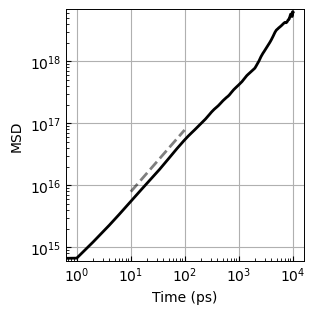

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep2/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep3/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep4/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep5/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep6/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/rep7/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01

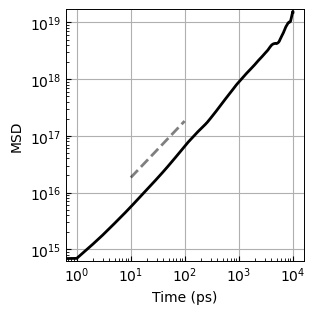

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep2/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep3/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep4/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep5/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep6/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep7/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/rep8/


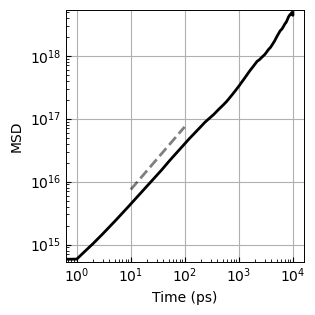

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep2/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep4/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep5/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep6/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep7/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/rep8/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01

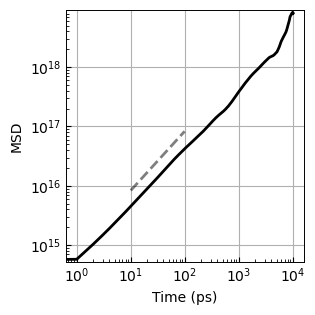

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep2/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep3/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep4/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep5/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep6/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/rep7/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01

In [36]:
#base_dir = "/home/mamurphy/"
base_dir = "/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/"
rerun = True
for cation in ['Cs', 'K', 'Na', 'Li']:
    for conc in ['0.01M']: #, '0.5M', '0.1M', '0.01M']:
        if conc == '1M' or conc == '0.5M':
            runs = [1,2,3,4,5]
        else:
            runs = [1,2,3,4,5,6,7,8,9,10]
        if cation == 'Na' and conc == '0.01M':
            runs = [1,2,4,5,6,7,8,9,10] # omitting rep3 for now but rerunning on anvil currently

        print(f'Analyzing {cation} {conc}')
        # ##### Original analysis
        cond_msds, times_all, cond_all, beta_all = analyze_conductivity_orig(runs, base_dir, cation, conc, start, end, run_start, samplingperiod, T, rerun)
        lij_msds, lij_all, lij_beta_all = onsager_transport_orig(runs, base_dir, cation, conc, start, end, run_start, samplingperiod, T, rerun)
        print('cond beta:', beta_all)
        print('lij beta:', lij_beta_all)

size of beta: (5, 5)
Cs beta:  [1.83504069 0.61670538 0.86952906 0.66770169 1.13389873]
    L+- values: [ 1.15306052 -2.4984289  -5.25161343 -2.87841802 -6.22578658]
size of beta: (5, 5)
Cs beta:  [-0.73773191  1.13239433  1.60020838  0.88479159  1.40065344]
    L+- values: [-0.61404636 -1.26861121 -1.06337429  0.75393019 -0.55811758]
size of beta: (5, 10)
Cs beta:  [2.28648206 1.33022893 1.26553861 1.66069704 1.37184316 0.58818426
 1.55736682 1.94314193 1.16812921 0.97125704]
    L+- values: [-0.13335752 -0.14489858  0.57338288 -0.1962074   0.18642437  0.07384507
 -0.6750251   0.21892471 -0.16838102 -0.24612554]
size of beta: (5, 10)
Cs beta:  [ 3.67194997  0.98456098  2.42061784  1.39812578  1.63226394  2.67079398
  2.23418991  1.72214199  0.47451261 -1.48350696]
    L+- values: [ 0.00206149 -0.01388023 -0.00439112  0.01175795  0.04150091 -0.00586006
 -0.00404154  0.00751633  0.02062845 -0.00392688]
size of beta: (5, 5)
K beta:  [1.38088805 1.24010814 1.39711802 1.3670973  0.58559848

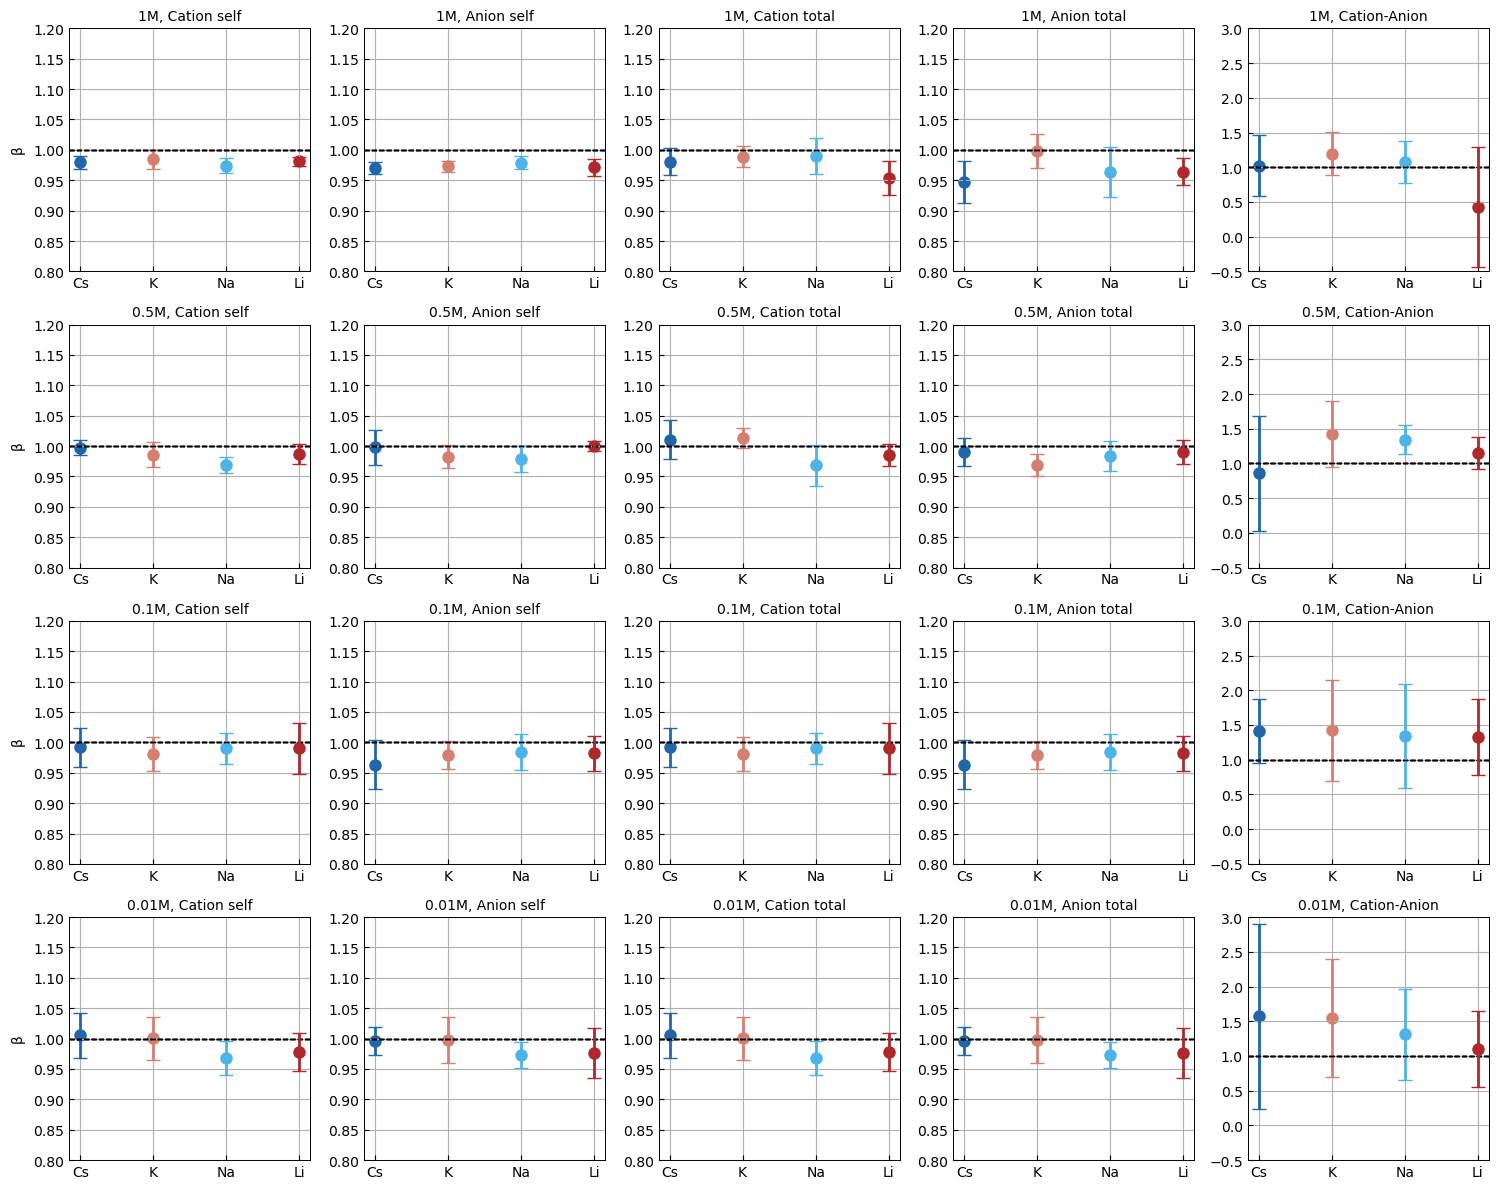

In [41]:
# plot beta values of the fits
path = "/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/data/"

fig, ax = plt.subplots(4,5, figsize=(15,12))
colors = ["#2066a8", "#d47f72",  "#4db4e8", "#ae282c"]
reps = [1]
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion']

for j, cation in enumerate(['Cs', 'K', 'Na', 'Li']):
    for k, conc in enumerate(concentrations):
        beta = np.load(f'{path}/{cation}/{conc}/total-transport/beta.npy')
        lij = np.load(f'{path}/{cation}/{conc}/total-transport/lij.npy')
        print("size of beta:", beta.shape)
        # print(lij)
        length = beta.shape[1]

        for i in range(5):
            # plot a black horizontal line at y=1
            ax[k,i].axhline(y=1, color='k', linestyle='--', linewidth=1)
            ax[k,i].scatter(j, np.mean(beta[i]), color=colors[j])
            ax[k,i].errorbar(j, np.mean(beta[i]), yerr=np.std(beta[i]), color=colors[j], capsize=5)
            if i == 4:
                print(cation, "beta: ", beta[i])
                print("    L+- values:", lij[i])
            ax[k,i].set_title(f"{conc}, {lij_names[i]}")
            ax[k,i].grid()
            ax[k,i].set_xticks(range(4))
            ax[k,i].set_xticklabels(['Cs', 'K', 'Na', 'Li'])
            if i == 0:
                ax[k,i].set_ylabel(r'$\beta$')
                
            if j == 0:
                ax[k,i].grid()

            if i != 4:
                ax[k,i].set_ylim(0.8, 1.2)
            else:
                ax[k,i].set_ylim(-0.5, 3)


plt.tight_layout()
plt.show()


In [44]:
## analyze finite size effect simulations
def analyze_conductivity_fs(runs, base_dir, cation, conc, size, start, end, run_start, samplingperiod, T, rerun=False):
        # script for analysis functions
        cond_msds = np.empty((len(runs)), dtype=object)
        times_all = np.empty((len(runs)), dtype=object)
        cond_all = np.empty((len(runs)), dtype=float)
        beta_all = np.empty((len(runs)), dtype=float) 

        folder = f'{base_dir}simulations/{cation}/{conc}/finite-size/box{size}/'

        for j, r in enumerate(runs):
                path = os.path.join(folder, f"rep{r}/")
                print(path)
                u = create_mda(
                        path,
                        data_file="system.data",
                        dcd_file="nvt_unwrapped_*.dcd",
                        cat_dcd=True,
                        )

                path = os.path.join(base_dir, f"data/{cation}/{conc}/finite-size/box{size}/rep{r}")

                if path is not None:
                        Path(path).mkdir(parents=True, exist_ok=True)

                msd, msd_var, times = ta.get_cond_msd(path, u, run_start, samplingperiod, dirs='xyz', T=T, rerun=rerun)

                cond_msds[j] = msd
                times_all[j] = times
                cond_all[j], _ = ta.fit_data(msd, times, start, end, weighted=True, msd_var=msd_var)
                _, beta_all[j] = ta.fit_data(msd, times, start, end, weighted=False)
                del u
                gc.collect()

        ta.make_one_msd_plot(times_all[0], cond_msds[0], start, end)

        return cond_msds, times_all, cond_all, beta_all

def onsager_transport_fs(runs, base_dir, cation, conc, size, start, end, run_start, samplingperiod, T, rerun=False):

    lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']
    lij_msds = np.empty((len(lij_names), len(runs)), dtype=object)
    lij_all = np.empty((len(lij_names), len(runs)), dtype=float)
    lij_beta_all = np.empty((len(lij_names), len(runs)), dtype=float) 

    folder = f'{base_dir}simulations/{cation}/{conc}/finite-size/box{size}/'

    for j, r in enumerate(runs):
        path = os.path.join(folder, f"rep{r}/")
        print(path) 
        u = create_mda(
                path,
                data_file="system.data",
                dcd_file="nvt_unwrapped_*.dcd",
                cat_dcd=True,)
        
        # define new folder to store transport data
        path = os.path.join(base_dir, f"data/{cation}/{conc}/finite-size/box{size}/rep{r}")
        msds, msd_vars, times = ta.get_lij_msds(path, u, run_start, samplingperiod, dirs='xyz', T=T, rerun=rerun)
        for l in range(len(lij_names)):
            lij_msds[l,j] = msds[l] 
        lij_all[:,j], _ = ta.fit_all_msds(lij_msds[:,j], times, start=start, end=end, weighted=True, msd_var=msd_vars)
        _, lij_beta_all[:,j] = ta.fit_all_msds(lij_msds[:,j], times, start=start, end=end, weighted=False)
        del u
        gc.collect()

    path = os.path.join(base_dir, f"data/{cation}/{conc}/finite-size/box{size}/total-transport")
    if path is not None:
        Path(path).mkdir(parents=True, exist_ok=True)
        
    np.save(f'{path}/lij.npy', lij_all)
    np.save(f'{path}/beta.npy', lij_beta_all)
    
    return lij_msds, lij_all, lij_beta_all

Analyzing Cs 0.01M box1
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep2/


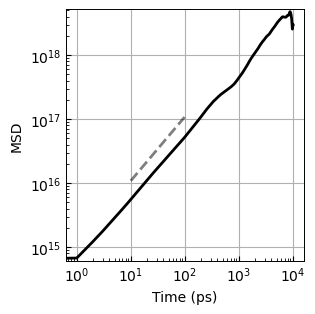

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep2/
Analyzing Cs 0.01M box2
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep2/


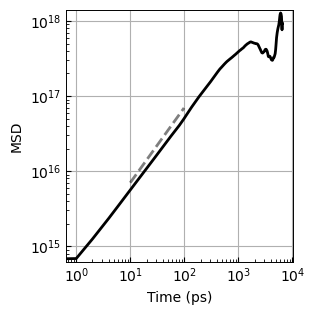

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep2/
Analyzing Cs 0.01M box3
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box3/rep2/


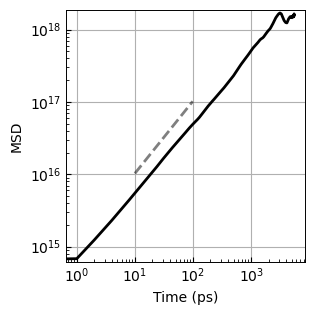

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box3/rep2/
Analyzing K 0.01M box1
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box1/rep2/


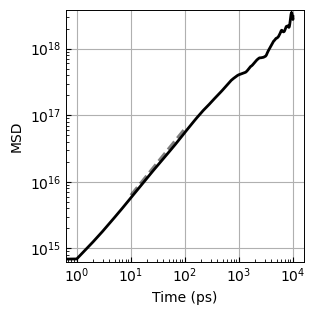

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box1/rep2/
Analyzing K 0.01M box2
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box2/rep2/


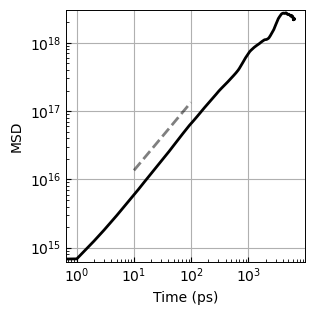

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box2/rep2/
Analyzing K 0.01M box3
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box3/rep2/


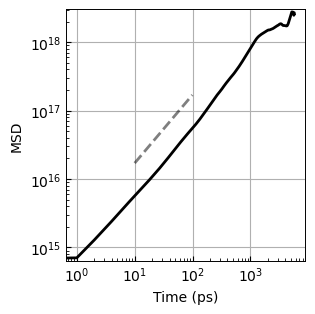

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/K/0.01M/finite-size/box3/rep2/
Analyzing Na 0.01M box1
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box1/rep2/


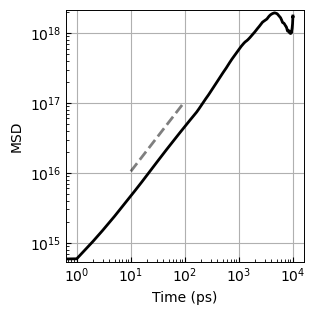

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box1/rep2/
Analyzing Na 0.01M box2
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box2/rep2/


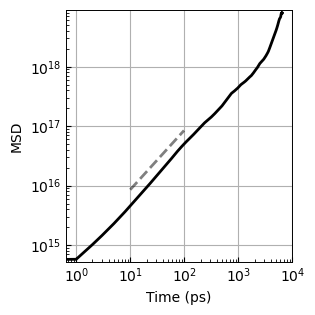

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box2/rep2/
Analyzing Na 0.01M box3
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box3/rep2/


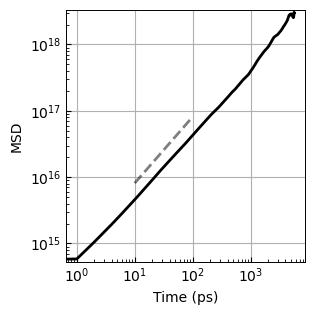

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Na/0.01M/finite-size/box3/rep2/
Analyzing Li 0.01M box1
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box1/rep2/


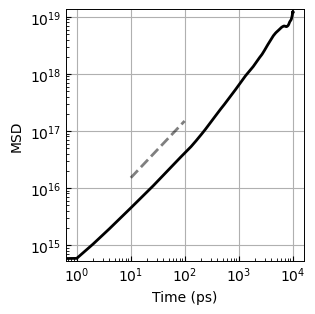

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box1/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box1/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box1/rep2/
Analyzing Li 0.01M box2
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box2/rep2/


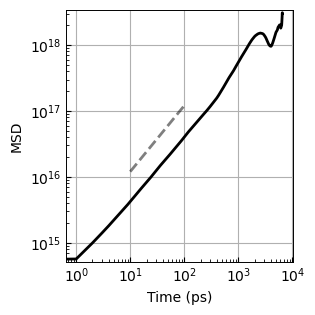

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box2/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box2/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box2/rep2/
Analyzing Li 0.01M box3
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box3/rep2/


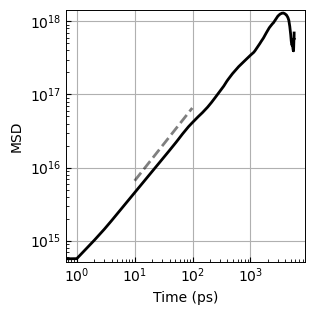

/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box3/rep0/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box3/rep1/
/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Li/0.01M/finite-size/box3/rep2/


In [53]:
#base_dir = "/home/mamurphy/"
base_dir = "/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/"
rerun = True
start = 10
end = 100
for cation in ['Cs', 'K', 'Na','Li']:
    for conc in ['0.01M']:
        for size in ['1', '2', '3']:
            runs = [0,1,2]

            print(f'Analyzing {cation} {conc} box{size}')
            ##### finite size analysis
            cond_msds, times_all, cond_all, beta_all = analyze_conductivity_fs(runs, base_dir, cation, conc, size, start, end, run_start, samplingperiod, T, rerun)
            lij_msds, lij_all, lij_beta_all = onsager_transport_fs(runs, base_dir, cation, conc, size, start, end, run_start, samplingperiod, T, rerun)

size of beta: (5, 3)
Cs beta:  [1.74428582 0.46019617 0.45110463]
    L+- values: [ 0.00887863  0.01070557 -0.00709648]
size of beta: (5, 3)
Cs beta:  [1.45429165 2.91254166 1.65258989]
    L+- values: [ 0.07847905 -0.00898501  0.04358362]
size of beta: (5, 3)
Cs beta:  [ 1.27248393 -0.20067518  2.04236097]
    L+- values: [0.04785571 0.01275108 0.01715349]
size of beta: (5, 3)
K beta:  [0.57030125 1.24904061 2.05095784]
    L+- values: [-0.00461844 -0.02543844  0.01641849]
size of beta: (5, 3)
K beta:  [1.22570686 2.19562754 1.67087801]
    L+- values: [-0.04852425 -0.01670209  0.01748596]
size of beta: (5, 3)
K beta:  [1.37485852 2.42189145 1.19171675]
    L+- values: [ 0.04360609 -0.00418028 -0.03476278]
size of beta: (5, 3)
Na beta:  [1.04573857 1.98686864 1.74847793]
    L+- values: [-0.02196638 -0.02955503 -0.00902155]
size of beta: (5, 3)
Na beta:  [0.80170527 0.94985165 1.90161271]
    L+- values: [ 0.00056876  0.0448936  -0.03085013]
size of beta: (5, 3)
Na beta:  [0.4083632  

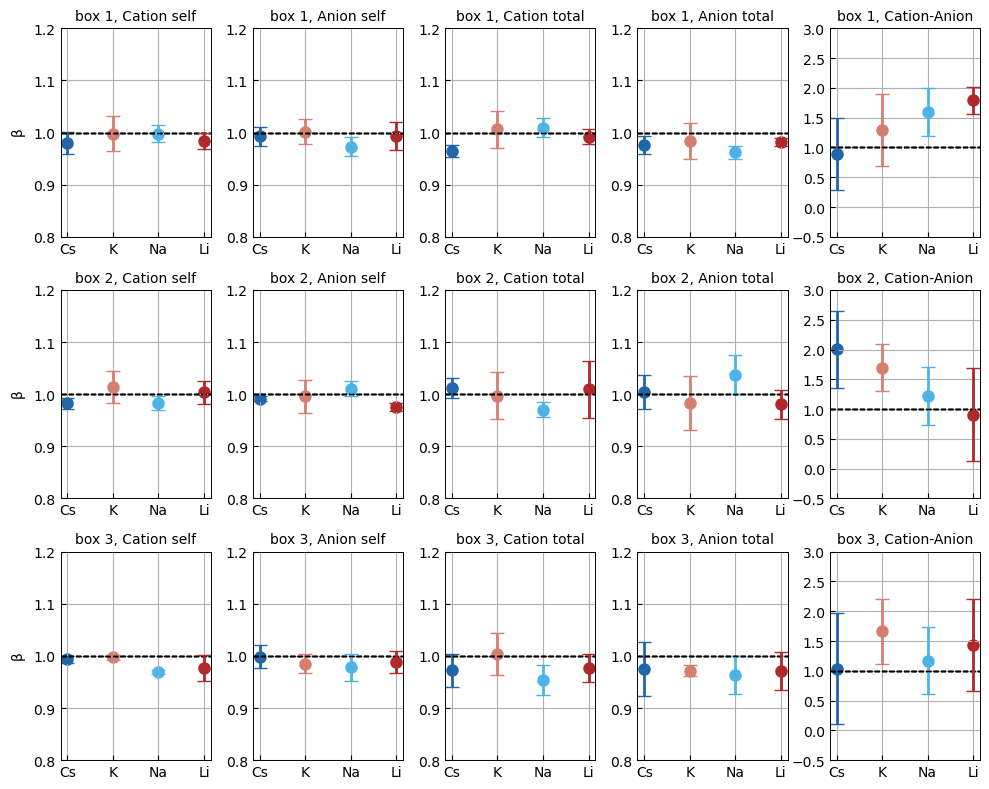

In [54]:
# plot beta values of the fits
path = "/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/data/"

fig, ax = plt.subplots(3,5, figsize=(10,8))
colors = ["#2066a8", "#d47f72",  "#4db4e8", "#ae282c"]
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
sizes = ['1', '2', '3']
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion']

for j, cation in enumerate(['Cs', 'K', 'Na', 'Li']):
    for k, size in enumerate(sizes):
        beta = np.load(f'{path}/{cation}/0.01M/finite-size/box{size}/total-transport/beta.npy')
        lij = np.load(f'{path}/{cation}/0.01M/finite-size/box{size}/total-transport/lij.npy')
        print("size of beta:", beta.shape)
        # print(lij)
        length = beta.shape[1]

        for i in range(5):
            # plot a black horizontal line at y=1
            ax[k,i].axhline(y=1, color='k', linestyle='--', linewidth=1)
            ax[k,i].scatter(j, np.mean(beta[i]), color=colors[j])
            ax[k,i].errorbar(j, np.mean(beta[i]), yerr=np.std(beta[i]), color=colors[j], capsize=5)
            if i == 4:
                print(cation, "beta: ", beta[i])
                print("    L+- values:", lij[i])
            ax[k,i].set_title(f"box {size}, {lij_names[i]}")
            ax[k,i].grid()
            ax[k,i].set_xticks(range(4))
            ax[k,i].set_xticklabels(['Cs', 'K', 'Na', 'Li'])
            if i == 0:
                ax[k,i].set_ylabel(r'$\beta$')
                
            if j == 0:
                ax[k,i].grid()

            if i != 4:
                ax[k,i].set_ylim(0.8, 1.2)
            else:
                ax[k,i].set_ylim(-0.5, 3)


plt.tight_layout()
plt.show()


In [55]:
# determine box sizes
import os
import re
import csv
import matplotlib.pyplot as plt

def extract_box_size(filepath):
    with open(filepath, 'r') as file:
        for line in file:
            if 'xlo xhi' in line:
                xlo, xhi = map(float, line.split()[:2])
            elif 'ylo yhi' in line:
                ylo, yhi = map(float, line.split()[:2])
            elif 'zlo zhi' in line:
                zlo, zhi = map(float, line.split()[:2])
    return xlo, xhi, ylo, yhi, zlo, zhi


base_dir = "/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/"
rerun = True
for cation in ['Cs', 'K', 'Na', 'Li']:
    for conc in ['1M', '0.5M', '0.1M', '0.01M']:
        if conc == '1M' or conc == '0.5M':
            runs = [1,2,3,4,5]
        else:
            runs = [1,2,3,4,5,6,7,8,9,10]
        if cation == 'Na' and conc == '0.01M':
            runs = [1,2,4,5,6,7,8,9,10] # omitting rep3 for now but rerunning on anvil currently

        print(f'Analyzing {cation} {conc}')
        folder = f'{base_dir}{cation}/{conc}/'
        box_sizes = []
        for r in runs: 
            path = os.path.join(folder, f"rep{r}/end_nvt.data")
            xlo, xhi, ylo, yhi, zlo, zhi = extract_box_size(path)
            box_size = (xhi - xlo)
            box_sizes.append(box_size)

        finite_size_folder = f'{base_dir}{cation}/{conc}/finite-size/box0/'
        if not os.path.exists(finite_size_folder):
            os.makedirs(finite_size_folder)

        np.save(f'{finite_size_folder}/box_sizes.npy', box_sizes)


for cation in ['Cs', 'K', 'Na', 'Li']:
    for conc in ['1M','0.5M', '0.1M', '0.01M']:
        runs = [0,1,2]

        print(f'Analyzing {cation} {conc}')
        folder = f'{base_dir}{cation}/{conc}/finite-size'
        for size in ['1', '2', '3']:
            folder = f'{base_dir}{cation}/{conc}/finite-size/box{size}/'
            box_sizes = []
            for r in runs: 
                path = os.path.join(folder, f"rep{r}/end_nvt.data")
                if not os.path.exists(path):
                    print(f"File {path} does not exist. using npt.")
                    path = os.path.join(folder, f"rep{r}/end_npt.data")

                xlo, xhi, ylo, yhi, zlo, zhi = extract_box_size(path)
                box_size = (xhi - xlo)
                box_sizes.append(box_size)
                
            if not os.path.exists(folder):
                os.makedirs(folder)
            # print(f'Saving box sizes for {cation} {conc} box{size}: box_sizes = {box_sizes}')
            np.save(f'{folder}/box_sizes.npy', box_sizes)

Analyzing Cs 1M
Analyzing Cs 0.5M
Analyzing Cs 0.1M
Analyzing Cs 0.01M
Analyzing K 1M
Analyzing K 0.5M
Analyzing K 0.1M
Analyzing K 0.01M
Analyzing Na 1M
Analyzing Na 0.5M
Analyzing Na 0.1M
Analyzing Na 0.01M
Analyzing Li 1M
Analyzing Li 0.5M
Analyzing Li 0.1M
Analyzing Li 0.01M
Analyzing Cs 1M
Analyzing Cs 0.5M
Analyzing Cs 0.1M
Analyzing Cs 0.01M
File /Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box1/rep2/end_nvt.data does not exist. using npt.
File /Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep0/end_nvt.data does not exist. using npt.
File /Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/simulations/Cs/0.01M/finite-size/box2/rep1/end_nvt.data does not exist. using npt.
File /Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/suppor

## Load finite size effects 

In [56]:
# finite size effects
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
conc_vals = [1.0, 0.5, 0.1, 0.01]  # molality values for the concentrations
cations = ['Cs', 'K', 'Na', 'Li']
sizes = ['0', '1', '2', '3']
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']

lij_all_array = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)), dtype=object)
beta_all_array = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)), dtype=object)
avg_lij_all = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)))
std_lij_all = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)))

cond_all = np.empty((len(cations), len(concentrations), len(sizes)), dtype=object)
avg_cond_all = np.empty((len(cations), len(concentrations), len(sizes)))
std_cond_all = np.empty((len(cations), len(concentrations), len(sizes)))

diff_all = np.empty((len(cations), len(concentrations), len(sizes), 2), dtype=object)
avg_diff_all = np.empty((len(cations), len(concentrations), len(sizes), 2))
std_diff_all = np.empty((len(cations), len(concentrations), len(sizes), 2))

box_sizes_all = np.empty((len(cations), len(concentrations), len(sizes)))

def cond(lij):
    return lij[2,:] + lij[3,:] - 2 * lij[4,:]

def self_diffusion_coeff(lij, conc):
    c = conc * 1e3  # mol/L to mol/m^3 conversion
    R = 8.314  # J/(mol*K)
    T = 298.15  # K
    return (lij * 0.1 / 96485**2) * (R * T /c) # m^2/s


folder = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/'
figure_folder = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/figures/finite-size/'

for k, cation in enumerate(cations):
    for j, conc in enumerate(concentrations):
        for s, size in enumerate(sizes):
            if s == 0:
                lij_all = np.load(f'{folder}data/{cation}/{conc}/total-transport/lij.npy')
                lij_beta_all = np.load(f'{folder}data/{cation}/{conc}/total-transport/beta.npy')

                for i in range(len(lij_names)):
                    lij_all_array[k,j,i,s] = lij_all[i,:]
                    beta_all_array[k,j,i,s] = lij_beta_all[i,:]
                avg_lij_all[k,j,:,s] = np.mean(lij_all, axis=1)
                std_lij_all[k,j,:,s] = np.std(lij_all, axis=1)

                cond_all[k,j,s] = cond(lij_all)
                avg_cond_all[k,j,s] = np.mean(cond(lij_all))
                std_cond_all[k,j,s] = np.std(cond(lij_all))

                diff_all[k,j,s,0] = self_diffusion_coeff(lij_all[0,:], conc_vals[j])
                diff_all[k,j,s,1] = self_diffusion_coeff(lij_all[1,:], conc_vals[j])
                avg_diff_all[k,j,s,0] = np.mean(self_diffusion_coeff(lij_all[0,:], conc_vals[j]))
                avg_diff_all[k,j,s,1] = np.mean(self_diffusion_coeff(lij_all[1,:], conc_vals[j]))
                std_diff_all[k,j,s,0] = np.std(self_diffusion_coeff(lij_all[0,:], conc_vals[j]))
                std_diff_all[k,j,s,1] = np.std(self_diffusion_coeff(lij_all[1,:], conc_vals[j]))


            else:
                lij_all = np.load(f'{folder}data/{cation}/{conc}/finite-size/box{size}/total-transport/lij.npy')
                lij_beta_all = np.load(f'{folder}data/{cation}/{conc}/finite-size/box{size}/total-transport/beta.npy')

                for i in range(len(lij_names)):
                    lij_all_array[k,j,i,s] = lij_all[i,:]
                    beta_all_array[k,j,i,s] = lij_beta_all[i,:]
                    if conc == '0.01M':
                        print(f'Box size {size} for {cation} {conc} has beta values: {lij_beta_all[i,:]}')
                avg_lij_all[k,j,:,s] = np.mean(lij_all, axis=1)
                std_lij_all[k,j,:,s] = np.std(lij_all, axis=1)

                cond_all[k,j,s] = cond(lij_all)
                avg_cond_all[k,j,s] = np.mean(cond(lij_all))
                std_cond_all[k,j,s] = np.std(cond(lij_all))

                diff_all[k,j,s,0] = self_diffusion_coeff(lij_all[0,:], conc_vals[j])
                diff_all[k,j,s,1] = self_diffusion_coeff(lij_all[1,:], conc_vals[j])
                avg_diff_all[k,j,s,0] = np.mean(self_diffusion_coeff(lij_all[0,:], conc_vals[j]))
                avg_diff_all[k,j,s,1] = np.mean(self_diffusion_coeff(lij_all[1,:], conc_vals[j]))
                std_diff_all[k,j,s,0] = np.std(self_diffusion_coeff(lij_all[0,:], conc_vals[j]))
                std_diff_all[k,j,s,1] = np.std(self_diffusion_coeff(lij_all[1,:], conc_vals[j]))

            # read in the box sizes
            box_sizes = np.load(f'{folder}simulations/{cation}/{conc}/finite-size/box{size}/box_sizes.npy')
            avg_box_size = np.mean(box_sizes)

            box_sizes_all[k,j,s] = avg_box_size


print(f'Box sizes: {box_sizes_all}')
print(f'Number of box sizes: {len(box_sizes_all)}')
print(f'Number of lij values: {lij_all.shape}')
print(lij_all[0:5,0])

print(avg_diff_all)

Box size 1 for Cs 0.01M has beta values: [0.98783035 0.95233198 1.00224744]
Box size 1 for Cs 0.01M has beta values: [1.01763385 0.9881898  0.97295116]
Box size 1 for Cs 0.01M has beta values: [0.96813384 0.94851008 0.97730091]
Box size 1 for Cs 0.01M has beta values: [0.99136154 0.98618328 0.95067286]
Box size 1 for Cs 0.01M has beta values: [1.74428582 0.46019617 0.45110463]
Box size 2 for Cs 0.01M has beta values: [0.99645177 0.97039851 0.98165806]
Box size 2 for Cs 0.01M has beta values: [0.9843375  0.99414726 0.99574669]
Box size 2 for Cs 0.01M has beta values: [1.03862944 0.99779679 0.99992772]
Box size 2 for Cs 0.01M has beta values: [0.96341487 1.00342488 1.04324586]
Box size 2 for Cs 0.01M has beta values: [1.45429165 2.91254166 1.65258989]
Box size 3 for Cs 0.01M has beta values: [1.0031591  0.98711161 0.99085565]
Box size 3 for Cs 0.01M has beta values: [1.01509677 0.96682927 1.01257989]
Box size 3 for Cs 0.01M has beta values: [0.93766938 1.01530172 0.96330115]
Box size 3 f

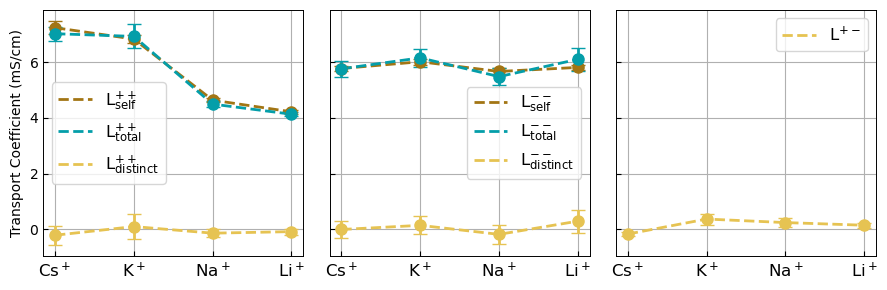

In [64]:
fig, ax = plt.subplots(1, 3, figsize=[9,3], sharey=True)
colors2 = ["#A27514", "#049ea9", "#e6c352"]
cation_vals = [1, 2, 3, 4]
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']
cation_labels = [r'Cs$^+$', r'K$^+$', r'Na$^+$', r'Li$^+$']
s=2  # box size 3
j=2  # 0.1M

ax[0].plot(cation_vals, avg_lij_all[:,j,0,s], label=r'L$^{++}_{self}$', color=colors2[0], linestyle='--')
ax[0].errorbar(cation_vals, avg_lij_all[:,j,0,s], yerr=std_lij_all[:,j,0,s], fmt='o', capsize=5, color=colors2[0])
ax[0].plot(cation_vals, avg_lij_all[:,j,2,s], label=r'L$^{++}_{total}$', color=colors2[1], linestyle='--')
ax[0].errorbar(cation_vals, avg_lij_all[:,j,2,s], yerr=std_lij_all[:,j,2,s], fmt='o', capsize=5, color=colors2[1])
ax[0].plot(cation_vals, avg_lij_all[:,j,2,s] - avg_lij_all[:,j,0,s], label=r'L$^{++}_{distinct}$', color=colors2[2], linestyle='--')
ax[0].errorbar(cation_vals, avg_lij_all[:,j,2,s] - avg_lij_all[:,j,0,s], yerr=np.sqrt(std_lij_all[:,j,2,s]**2 + std_lij_all[:,j,0,s]**2), fmt='o', capsize=5, color=colors2[2])
ax[0].set_xticks(cation_vals)
ax[0].set_xticklabels(cation_labels, fontsize=12)
ax[0].set_ylabel('Transport Coefficient (mS/cm)')

ax[1].plot(cation_vals, avg_lij_all[:,j,1,s], label=r'L$^{--}_{self}$', color=colors2[0], linestyle='--')
ax[1].errorbar(cation_vals, avg_lij_all[:,j,1,s], yerr=std_lij_all[:,j,1,s], fmt='o', capsize=5, color=colors2[0])
ax[1].plot(cation_vals, avg_lij_all[:,j,3,s], label=r'L$^{--}_{total}$', color=colors2[1], linestyle='--')
ax[1].errorbar(cation_vals, avg_lij_all[:,j,3,s], yerr=std_lij_all[:,j,3,s], fmt='o', capsize=5, color=colors2[1])
ax[1].plot(cation_vals, avg_lij_all[:,j,3,s] - avg_lij_all[:,j,1,s], label=r'L$^{--}_{distinct}$', color=colors2[2], linestyle='--')
ax[1].errorbar(cation_vals, avg_lij_all[:,j,3,s] - avg_lij_all[:,j,1,s], yerr=np.sqrt(std_lij_all[:,j,3,s]**2 + std_lij_all[:,j,1,s]**2), fmt='o', capsize=5, color=colors2[2])
ax[1].set_xticks(cation_vals)
ax[1].set_xticklabels(cation_labels, fontsize=12)

ax[2].plot(cation_vals, avg_lij_all[:,j,4,s], label=r'L$^{+-}$', color=colors2[2], linestyle='--')
ax[2].errorbar(cation_vals, avg_lij_all[:,j,4,s], yerr=std_lij_all[:,j,4,s], fmt='o', capsize=5, color=colors2[2])
ax[2].set_xticks(cation_vals)
ax[2].set_xticklabels(cation_labels, fontsize=12)

for i in range(3):
    ax[i].grid()
    ax[i].legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f'{figure_folder}01_lij_3ions.png', dpi=300)

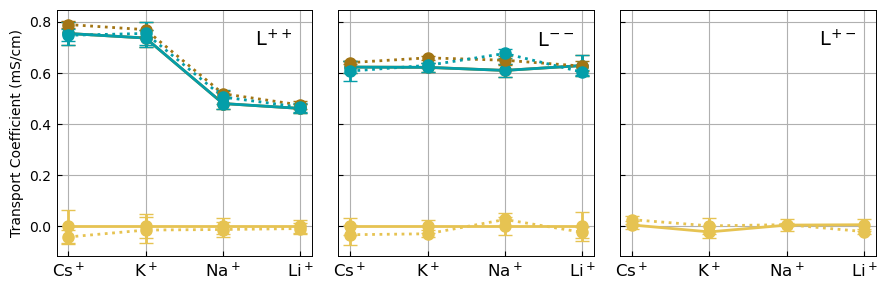

In [65]:
fig, ax = plt.subplots(1, 3, figsize=[9,3], sharey=True)
colors2 = ["#A27514", "#049ea9", "#e6c352"]
cation_vals = [1, 2, 3, 4]
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']
cation_labels = [r'Cs$^+$', r'K$^+$', r'Na$^+$', r'Li$^+$']

j=3  # 0.01M
linestyle = ['-', ':', ':',':']

for s in [0,3]:
    ax[0].plot(cation_vals, avg_lij_all[:,j,0,s], label=r'L$^{++}_{self}$', color=colors2[0], linestyle=linestyle[s])
    ax[0].errorbar(cation_vals, avg_lij_all[:,j,0,s], yerr=std_lij_all[:,j,0,s], fmt='o', capsize=5, color=colors2[0])
    ax[0].plot(cation_vals, avg_lij_all[:,j,2,s], label=r'L$^{++}_{total}$', color=colors2[1], linestyle=linestyle[s])
    ax[0].errorbar(cation_vals, avg_lij_all[:,j,2,s], yerr=std_lij_all[:,j,2,s], fmt='o', capsize=5, color=colors2[1])
    ax[0].plot(cation_vals, avg_lij_all[:,j,2,s] - avg_lij_all[:,j,0,s], label=r'L$^{++}_{distinct}$', color=colors2[2], linestyle=linestyle[s])
    ax[0].errorbar(cation_vals, avg_lij_all[:,j,2,s] - avg_lij_all[:,j,0,s], yerr=np.sqrt(std_lij_all[:,j,2,s]**2 + std_lij_all[:,j,0,s]**2), fmt='o', capsize=5, color=colors2[2])
    ax[0].set_xticks(cation_vals)
    ax[0].set_xticklabels(cation_labels, fontsize=12)
    ax[0].set_ylabel('Transport Coefficient (mS/cm)')

    ax[1].plot(cation_vals, avg_lij_all[:,j,1,s], label=r'L$^{--}_{self}$', color=colors2[0], linestyle=linestyle[s])
    ax[1].errorbar(cation_vals, avg_lij_all[:,j,1,s], yerr=std_lij_all[:,j,1,s], fmt='o', capsize=5, color=colors2[0])
    ax[1].plot(cation_vals, avg_lij_all[:,j,3,s], label=r'L$^{--}_{total}$', color=colors2[1], linestyle=linestyle[s])
    ax[1].errorbar(cation_vals, avg_lij_all[:,j,3,s], yerr=std_lij_all[:,j,3,s], fmt='o', capsize=5, color=colors2[1])
    ax[1].plot(cation_vals, avg_lij_all[:,j,3,s] - avg_lij_all[:,j,1,s], label=r'L$^{--}_{distinct}$', color=colors2[2], linestyle=linestyle[s])
    ax[1].errorbar(cation_vals, avg_lij_all[:,j,3,s] - avg_lij_all[:,j,1,s], yerr=np.sqrt(std_lij_all[:,j,3,s]**2 + std_lij_all[:,j,1,s]**2), fmt='o', capsize=5, color=colors2[2])
    ax[1].set_xticks(cation_vals)
    ax[1].set_xticklabels(cation_labels, fontsize=12)

    ax[2].plot(cation_vals, avg_lij_all[:,j,4,s], label=r'L$^{+-}$', color=colors2[2], linestyle=linestyle[s])
    ax[2].errorbar(cation_vals, avg_lij_all[:,j,4,s], yerr=std_lij_all[:,j,4,s], fmt='o', capsize=5, color=colors2[2])
    ax[2].set_xticks(cation_vals)
    ax[2].set_xticklabels(cation_labels, fontsize=12)

labels = [r'L$^{++}$', r'L$^{--}$', r'L$^{+-}$']
for i in range(3):
    ax[i].grid()
    ax[i].set_title(labels[i], fontsize=14, x =0.85, y=0.82)
    # ax[i].legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f'{figure_folder}001_lij_1_vs_3.png', dpi=300)

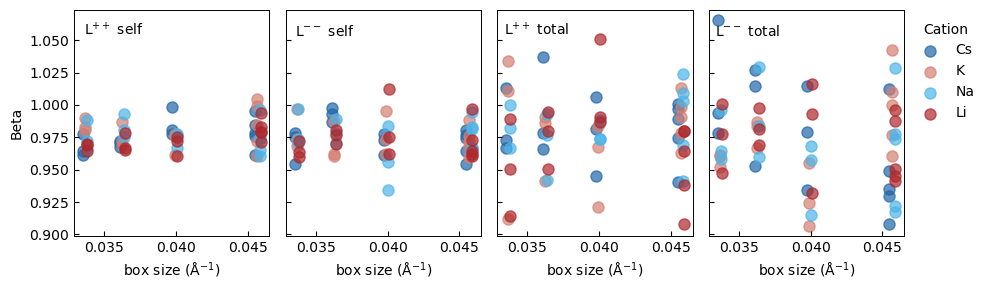

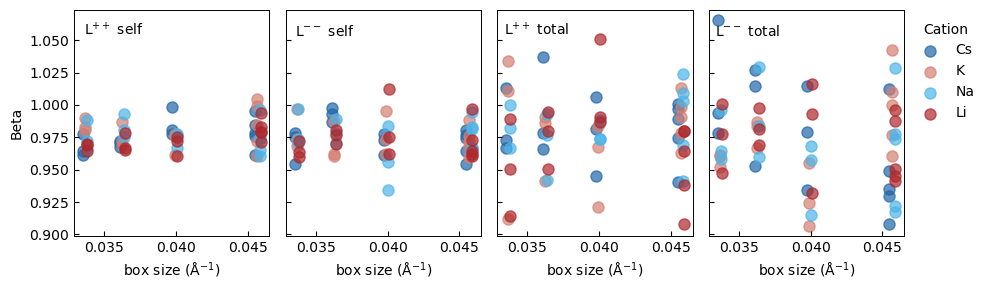

In [67]:
# plot beta values for each cation and concentration and lij name
lij_labels = [r'$L^{++}$ self', r'$L^{--}$ self', r'$L^{++}$ total', r'$L^{--}$ total', r'$L^{+-}$']
fig, ax = plt.subplots(1, 4, figsize=[10,3], sharex=True, sharey=True)
sizes = ['0', '1', '2', '3']

plot_labels = lij_labels[:-1] 
for i, cation in enumerate(cations):
    for k, label in enumerate(plot_labels):
        for j, size in enumerate(sizes):
            size_array = np.full_like(beta_all_array[i,0,k,j], 1/box_sizes_all[i,0,j], dtype=float)
            if j == 0:
                ax[k].scatter(size_array, beta_all_array[i,0,k,j], alpha=0.7, color=colors[i], label=f'{cation}')
            else:
                ax[k].scatter(size_array, beta_all_array[i,0,k,j], alpha=0.7, color=colors[i])


        ax[k].set_title(f'{label}', x=0.2, y=0.85)
        ax[k].set_xlabel(r'box size ($\AA^{-1}$)')
        ax[0].set_ylabel('Beta')
        ax[k].grid()
        ax[3].legend(title='Cation', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()
plt.show()

## Finite Size Effects fitting

In [85]:
conc = '0.01M'
j = concentrations.index(conc)
# fit the data to a line restricted to the same slope for all lij values
from scipy.stats import linregress
def fit_lij_data(box_sizes, lij_values):
    slope, intercept, r_value, p_value, std_err = linregress(box_sizes, lij_values)
    # print(f' r^2 was {r_value**2}')
    return slope, intercept, r_value**2

def calc_rsquared(y, fit):
    residuals = y - fit
    ss_res = np.sum((residuals)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)

    return r_squared


def fit_lij_data_indiv(box_sizes, lij_values):
    slopes = []
    intercepts = []
    r_squared = []
    for i in range(len(lij_values)):
        slope, intercept, r_squared_val = fit_lij_data(box_sizes, lij_values[i])
        slopes.append(slope)
        intercepts.append(intercept)
        r_squared.append(r_squared_val)
    print(f'three slopes: {slopes}')
    avg_slope = np.mean(slopes)

    return avg_slope, np.array(intercepts), slopes, r_squared

def fit_lij_data_fixed_slope(box_sizes, lij_values, slope):
    intercepts = []
    r_squared = []
    for i in range(len(lij_values)):
        intercept = lij_values[i] - slope * box_sizes
        intercepts.append(np.mean(intercept))

        # compute r^2
        r_squared.append(calc_rsquared(lij_values[i], slope * box_sizes + intercepts[i]))
        # print(f'R^2 for {lij_names[i]}: {r_squared}')
    return np.array(intercepts), r_squared

# fit the lij data
def full_fit_lij_data(box_sizes, avg_lij_values):
    avg_slope, intercepts, slopes, r_squared = fit_lij_data_indiv(1/box_sizes, avg_lij_values)
    print(f'Average slope: {avg_slope}')
    intercepts_fixed_slope, fixed_r_squared = fit_lij_data_fixed_slope(1/box_sizes, avg_lij_values, avg_slope)

    return avg_slope, intercepts_fixed_slope, intercepts, slopes, fixed_r_squared, r_squared

def full_fit_shifted(box_sizes, avg_lij_values_shifted):
    # make on array of the shifted lij values
    lij = []
    sizes = []
    for i in range(3):
        lij.append(avg_lij_values_shifted[i])
        sizes.append(1/box_sizes)
    
    lij = np.concatenate(lij)
    sizes = np.concatenate(sizes)

    print(sizes)
    print(lij)
    slope, intercept, r_squared = fit_lij_data(sizes, lij)
    return slope, intercept, r_squared

large_box_limit = np.zeros((len(cations), 3))
avg_slopes = np.zeros((len(cations)))
slopes = np.zeros((len(cations), 3))
intercepts = np.zeros((len(cations), 3))

r_squared_values = np.zeros((len(cations), 3))
fixed_r_squared_values = np.zeros((len(cations), 3))

slope_shifted = np.zeros((len(cations), 3))
intercepts_shifted= np.zeros((len(cations), 3))
r_squared_shifted = np.zeros((len(cations), 3))
shifted_slope_all = np.zeros((len(cations)))
shifted_intercepts_fixed_slope = np.zeros((len(cations)))
fixed_shifted_r_squared = np.zeros((len(cations)))


for k, cation in enumerate(cations):
    print(f'Fitting lij data for {cation}')
    # only fit total cation and anion lij values and cation-anion lij values
    avg_slopes[k], intercepts_fixed_slope, intercepts[k], slopes[k], fixed_r_squared_values[k], r_squared_values[k] = full_fit_lij_data(box_sizes_all[k,j,1:], avg_lij_all[k,j,2:,1:])

    # shifted values
    shifted_lij = np.empty((3), dtype=object)
    for i in range(3):
        shifted_lij[i] = np.subtract(avg_lij_all[k,j,i+2,1:], avg_lij_all[k,j,i+2,1])
    hold, hold, intercepts_shifted[k], slope_shifted[k], hold, r_squared_shifted[k] = full_fit_lij_data(box_sizes_all[k,j,1:], shifted_lij)
    
    print(f'shifted: {slope_shifted[k]}, {intercepts_shifted[k]}, {r_squared_shifted[k]}')

    shifted_slope_all[k], shifted_intercepts_fixed_slope[k], fixed_shifted_r_squared[k] = full_fit_shifted(box_sizes_all[k,j,1:], shifted_lij)
    # print(f'Average slope for {cation}: {avg_slopes[k]}')
    # print(f'Intercepts for {cation}: {intercepts_fixed_slope}')
    large_box_limit[k,:] = intercepts_fixed_slope
 

Fitting lij data for Cs
three slopes: [-6.5889565014282265, 14.675974355942676, -8.393982765788877]
Average slope: -0.10232163709147575
three slopes: [-6.5889565014282265, 14.675974355942676, -8.393982765788877]
Average slope: -0.10232163709147575
shifted: [-6.5889565  14.67597436 -8.39398277], [ 0.10428159 -0.2087162   0.1254985 ], [0.16426301 0.96874549 0.53783393]
[0.01434001 0.01253403 0.01139241 0.01434001 0.01253403 0.01139241
 0.01434001 0.01253403 0.01139241]
[ 0.          0.04698779  0.01372096  0.         -0.02028099 -0.04427006
  0.          0.03352998  0.02175752]
Fitting lij data for K
three slopes: [6.12637295852911, -2.294160092878124, -1.3049493577493136]
Average slope: 0.8424211693005574
three slopes: [6.12637295852911, -2.2941600928781245, -1.3049493577493134]
Average slope: 0.8424211693005574
shifted: [ 6.12637296 -2.29416009 -1.30494936], [-0.08459729  0.03961004  0.01488338], [0.60581009 0.048703   0.04827455]
[0.01434227 0.01252773 0.01138206 0.01434227 0.01252773

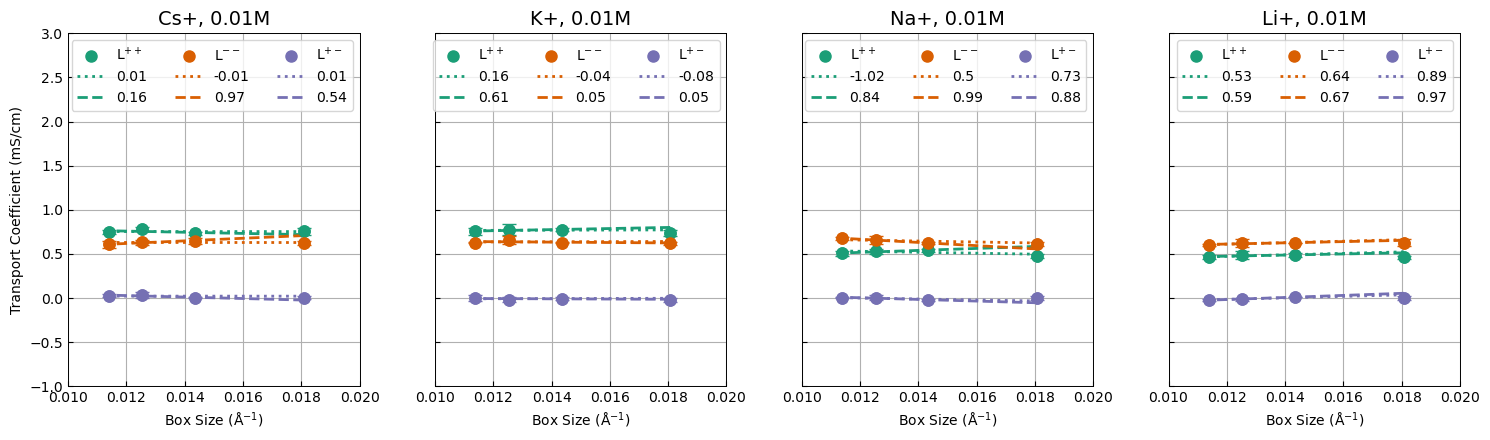

In [89]:
# plot the individual fits vs the average fit
import matplotlib.pyplot as plt
import numpy as np
j = concentrations.index(conc)
fig, ax = plt.subplots(1, 4, figsize=(15, 4.5), sharey=True, sharex=True)
lij_labels = [r'$L^{++}$', r'$L^{--}$', r'$L^{+-}$']

for k, cation in enumerate(cations):
    # plot the individual lij values
    for i in range(3):
        ax[k].scatter(1/box_sizes_all[k,j,:], avg_lij_all[k,j,i+2,:], label=f'{lij_labels[i]}', color=plt.get_cmap('Dark2')(i))
        ax[k].errorbar(1/box_sizes_all[k,j,:], avg_lij_all[k,j,i+2,:], yerr=std_lij_all[k,j,i+2,:], fmt='o', capsize=5, color=plt.get_cmap('Dark2')(i))

        # plot the average fit
        r_squared = fixed_r_squared_values[k,i]
        ax[k].plot(1/box_sizes_all[k,j,:], avg_slopes[k] * (1/box_sizes_all[k,j,:]) + large_box_limit[k,i], label=f'{np.round(r_squared,2)}', color=plt.get_cmap('Dark2')(i), linestyle=':')
        # print r_squared value

        # r_squared = fixed_r_squared_values[k,i]
        # if k == 0 or k == 1:
        #     ax[k].text(0.04, 30-(i*12), f'$R^2$ = {r_squared:.2f}', fontsize=12, color='k')
        # else:
        #     ax[k].text(0.04, 30-(i*12), f'$R^2$ = {r_squared:.2f}', fontsize=12, color='k')



        # plot the individual fit
        r_squared = r_squared_values[k,i]
        ax[k].plot(1/box_sizes_all[k,j,:], slopes[k,i] * (1/box_sizes_all[k,j,:]) + intercepts[k,i], label=f'{np.round(r_squared,2)}', color=plt.get_cmap('Dark2')(i), linestyle='--')
        

        # if k == 0 or k == 1:
        #     ax[k].text(0.04, 25-(i*12), f'$R^2$ = {r_squared:.2f}', fontsize=12, color=colors[i])
        # else:
        #     if i == 1:
        #         ax[k].text(0.04, 25, f'$R^2$ = {r_squared:.2f}', fontsize=12, color=colors[i])
        #     elif i == 2:
        #         ax[k].text(0.04, 25-(i*12), f'$R^2$ = {r_squared:.2f}', fontsize=12, color=colors[i])
        #     elif i == 0:
        #         ax[k].text(0.04, 25-(12), f'$R^2$ = {r_squared:.2f}', fontsize=12, color=colors[i])


    ax[k].set_title(f'{cation}+, {conc}', fontsize=14)
    ax[k].set_xlabel('Box Size ($\AA^{-1}$)')
    ax[0].set_ylabel('Transport Coefficient (mS/cm)')
    ax[k].set_xlim(0.01, 0.02)
    ax[k].set_ylim(-1, 3)

    ax[k].grid()
    ax[k].legend(fontsize=10, ncols=3, frameon=True)
plt.tight_layout()
plt.show()
fig.savefig(f'{figure_folder}lij-fits-{conc}.png', dpi=300)


In [90]:
# fit the diffusion coefficients to a line
conc = '1M'
j = concentrations.index(conc)
print(f'Fitting diffusion coefficients for {conc}, j={j}')

def fit_diffusion_data(box_sizes, diff_values):
    slope, intercept, r_value, p_value, std_err = linregress(box_sizes, diff_values)
    return slope, intercept, r_value**2
infinite_size_limit = np.zeros((len(cations), 2))
avg_slopes = np.zeros((len(cations), 2))

# plot the self diffusion coefficients
fig, ax = plt.subplots(1, 4, figsize=[15,4.5])
for k, cation in enumerate(cations):
    print(f'Plotting self diffusion coefficients for {cation}')
    ax[k].scatter(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,0], color=colors[0])
    ax[k].errorbar(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,0], yerr=std_diff_all[k,j,:,0], fmt='o', capsize=5, color=colors[0])
    slope, intercept, r_squared = fit_diffusion_data(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,0])
    infinite_size_limit[k,0] = intercept
    avg_slopes[k,0] = slope
    print(f'Slope: {slope}, Intercept: {intercept} for Cation self diffusion')
    ax[k].plot(1/box_sizes_all[k,j,:], slope * (1/box_sizes_all[k,j,:]) + intercept, linestyle='--', color=colors[0], label=f'Cation, $r^2$={r_squared:.2f}, slope: {slope:.1e}')

    ax[k].scatter(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,1], color=colors[1])
    ax[k].errorbar(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,1], yerr=std_diff_all[k,j,:,1], fmt='o', capsize=5, color=colors[1])
    slope, intercept, r_squared = fit_diffusion_data(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,1])
    ax[k].plot(1/box_sizes_all[k,j,:], slope * (1/box_sizes_all[k,j,:]) + intercept, linestyle='--', color=colors[1], label=f'Anion, $r^2$={r_squared:.2f}, slope: {slope:.1e}')
    print(f'Slope: {slope}, Intercept: {intercept} for Anion self diffusion')
    infinite_size_limit[k,1] = intercept
    avg_slopes[k,1] = slope

    ax[k].set_xlabel(r'Box Size ($\AA^{-1}$)', fontsize=12)
    ax[0].set_ylabel(r'Self Diffusion Coefficient ($m^2/s$)', fontsize=12)
    ax[k].set_title('cation: {cation}'.format(cation=cation) + r'$^+$', fontsize=14, y=0.87, x=0.8)
    ax[k].set_xlim(0.01, 0.02)
    ax[k].set_ylim(0.8e-9, 2.5e-9)
    ax[k].grid()
    if k == 0 or k == 1:
        ax[k].legend(fontsize=10, frameon=True, loc='lower left')
    else:
        ax[k].legend(fontsize=10, frameon=True, loc='center right', bbox_to_anchor=(1.0, 0.7))
plt.tight_layout()
fig.savefig(f'{figure_folder}self-diffusion-fits-{conc}.png', dpi=300)
np.save(f'{folder}data/finite-size/{conc}/infinite-size-limit-diffusion.npy', infinite_size_limit)
np.save(f'{folder}data/finite-size/{conc}/slopes-diffusion.npy', avg_slopes)

Fitting diffusion coefficients for 1M, j=0
Plotting self diffusion coefficients for Cs
Slope: -8.217765769439147e-09, Intercept: 1.9044365171193922e-09 for Cation self diffusion
Slope: -9.008976854150165e-09, Intercept: 1.6891435042358882e-09 for Anion self diffusion
Plotting self diffusion coefficients for K
Slope: -5.413238256045872e-09, Intercept: 1.7889200374758652e-09 for Cation self diffusion
Slope: -6.658203738303334e-09, Intercept: 1.5821577756689444e-09 for Anion self diffusion
Plotting self diffusion coefficients for Na
Slope: -7.515777992121996e-09, Intercept: 1.312809344157532e-09 for Cation self diffusion
Slope: -6.1002007958055205e-09, Intercept: 1.4482795059813202e-09 for Anion self diffusion
Plotting self diffusion coefficients for Li
Slope: -6.129333104099358e-09, Intercept: 1.1619122030093452e-09 for Cation self diffusion
Slope: -6.095004565946762e-09, Intercept: 1.4275703720574793e-09 for Anion self diffusion


Fitting diffusion coefficients for 0.01M, j=3
Plotting self diffusion coefficients for Cs
Slope: -1.3116531003910249e-08, Intercept: 2.2277881964631362e-09 for Cation self diffusion
Slope: -5.269854262961067e-09, Intercept: 1.761248638182271e-09 for Anion self diffusion
Plotting self diffusion coefficients for K
Slope: -1.5625724026037805e-08, Intercept: 2.2582048766277693e-09 for Cation self diffusion
Slope: -1.3760066866926163e-08, Intercept: 1.9040244318075727e-09 for Anion self diffusion
Plotting self diffusion coefficients for Na
Slope: -1.5630707822352487e-08, Intercept: 1.5810305193595532e-09 for Cation self diffusion
Slope: -1.61443428533235e-08, Intercept: 1.9152946159350966e-09 for Anion self diffusion
Plotting self diffusion coefficients for Li
Slope: -5.640096538938715e-09, Intercept: 1.333713772297828e-09 for Cation self diffusion
Slope: 5.571236433048155e-10, Intercept: 1.6685133928269144e-09 for Anion self diffusion


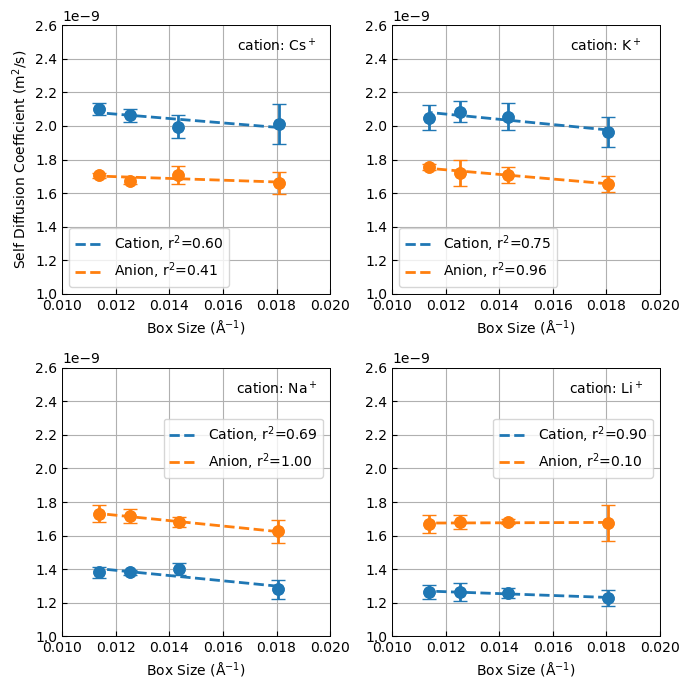

In [113]:
# fit the diffusion coefficients to a line
conc = '0.01M'
j = concentrations.index(conc)
print(f'Fitting diffusion coefficients for {conc}, j={j}')
colors = ['#1f77b4', '#ff7f0e']

def fit_diffusion_data(box_sizes, diff_values):
    slope, intercept, r_value, p_value, std_err = linregress(box_sizes, diff_values)
    return slope, intercept, r_value**2
infinite_size_limit = np.zeros((len(cations), 2))
avg_slopes = np.zeros((len(cations), 2))

# plot the self diffusion coefficients
fig, axes = plt.subplots(2, 2, figsize=[7,7])
ax = axes.flatten()
for k, cation in enumerate(cations):
    print(f'Plotting self diffusion coefficients for {cation}')
    ax[k].scatter(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,0], color=colors[0])
    ax[k].errorbar(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,0], yerr=std_diff_all[k,j,:,0], fmt='o', capsize=5, color=colors[0])
    slope, intercept, r_squared = fit_diffusion_data(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,0])
    infinite_size_limit[k,0] = intercept
    avg_slopes[k,0] = slope
    print(f'Slope: {slope}, Intercept: {intercept} for Cation self diffusion')
    ax[k].plot(1/box_sizes_all[k,j,:], slope * (1/box_sizes_all[k,j,:]) + intercept, linestyle='--', color=colors[0], label=f'Cation, $r^2$={r_squared:.2f}')

    ax[k].scatter(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,1], color=colors[1])
    ax[k].errorbar(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,1], yerr=std_diff_all[k,j,:,1], fmt='o', capsize=5, color=colors[1])
    slope, intercept, r_squared = fit_diffusion_data(1/box_sizes_all[k,j,:], avg_diff_all[k,j,:,1])
    ax[k].plot(1/box_sizes_all[k,j,:], slope * (1/box_sizes_all[k,j,:]) + intercept, linestyle='--', color=colors[1], label=f'Anion, $r^2$={r_squared:.2f}')
    print(f'Slope: {slope}, Intercept: {intercept} for Anion self diffusion')
    infinite_size_limit[k,1] = intercept
    avg_slopes[k,1] = slope

    ax[k].set_xlabel(r'Box Size ($\AA^{-1}$)', fontsize=10)
    ax[0].set_ylabel(r'Self Diffusion Coefficient ($m^2/s$)', fontsize=10)
    ax[k].set_title('cation: {cation}'.format(cation=cation) + r'$^+$', fontsize=10, y=0.87, x=0.8)
    ax[k].set_xlim(0.01, 0.02)
    ax[k].set_ylim(1.0e-9, 2.6e-9)
    ax[k].grid()
    if k == 0 or k == 1:
        ax[k].legend(fontsize=10, frameon=True, loc='lower left')
    else:
        ax[k].legend(fontsize=10, frameon=True, loc='center right', bbox_to_anchor=(1.0, 0.7))
plt.tight_layout()
plt.show()
fig.savefig(f'{figure_folder}self-diffusion-fits-{conc}.png', dpi=300)

np.save(f'{folder}data/finite-size/{conc}/infinite-size-limit-diffusion.npy', infinite_size_limit)
np.save(f'{folder}data/finite-size/{conc}/slopes-diffusion.npy', avg_slopes)

In [162]:
print(f'Large box limit: {large_box_limit}')

Large box limit: [[8.00067409 6.51286444 0.81909267]
 [7.64569715 6.51535846 0.8259748 ]
 [5.41519908 6.53912151 0.90161225]
 [4.83943122 6.42080103 0.69121482]]


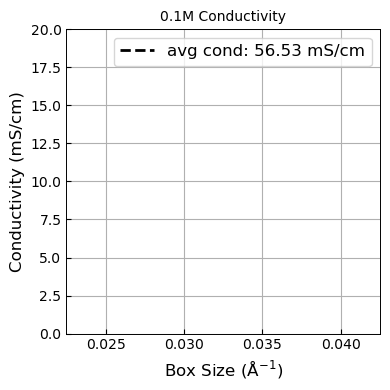

In [63]:
# plot the conductivity
fig, ax = plt.subplots(1, 1, figsize=[4,4])
k = 0  # index for cation
ax.scatter(1/box_sizes_all[k,:], avg_cond_all[k,:], color='k')
ax.errorbar(1/box_sizes_all[k,:], avg_cond_all[k,:], yerr=std_cond_all[k,:], fmt='o', capsize=5, color='k')  

ax.plot(1/box_sizes_all[k,:], np.ones(len(box_sizes_all[k,:])) * np.mean(avg_cond_all[k,:]), linestyle='--', color='k', label=f'avg cond: {np.mean(avg_cond_all[k,:]):.2f} mS/cm')

ax.set_xlabel(r'Box Size ($\AA^{-1}$)', fontsize=12)
ax.set_ylabel('Conductivity (mS/cm)', fontsize=12)
ax.set_title('0.1M Conductivity')
ax.set_xlim(0.0225, 0.0425)
ax.set_ylim(0, 20)
ax.grid()
ax.legend(fontsize=12, frameon=True)
plt.tight_layout()

[[[[1.58915136e-09 1.30180618e-09]
   [1.61913099e-09 1.34498175e-09]
   [1.63081051e-09 1.38647370e-09]
   [1.65679030e-09 1.39243915e-09]]

  [[1.74933429e-09 1.39660942e-09]
   [1.77020877e-09 1.45255715e-09]
   [1.81468915e-09 1.50197880e-09]
   [1.80747358e-09 1.51109943e-09]]

  [[1.84250507e-09 1.45767804e-09]
   [1.97209871e-09 1.59108212e-09]
   [1.94552468e-09 1.54441084e-09]
   [1.96495342e-09 1.58821905e-09]]

  [[2.01538481e-09 1.66189727e-09]
   [2.05689758e-09 1.70449331e-09]
   [2.11604265e-09 1.71211237e-09]
   [2.11967705e-09 1.72407721e-09]]]


 [[[1.56658550e-09 1.30181257e-09]
   [1.58007941e-09 1.33910248e-09]
   [1.60429192e-09 1.35221447e-09]
   [1.61896346e-09 1.36790883e-09]]

  [[1.66110384e-09 1.37394477e-09]
   [1.69649194e-09 1.46206053e-09]
   [1.74221070e-09 1.46970654e-09]
   [1.78091962e-09 1.47194211e-09]]

  [[1.77287567e-09 1.44634004e-09]
   [1.93636165e-09 1.51777607e-09]
   [1.82555527e-09 1.61040377e-09]
   [1.94446158e-09 1.56740546e-09]]

  [[

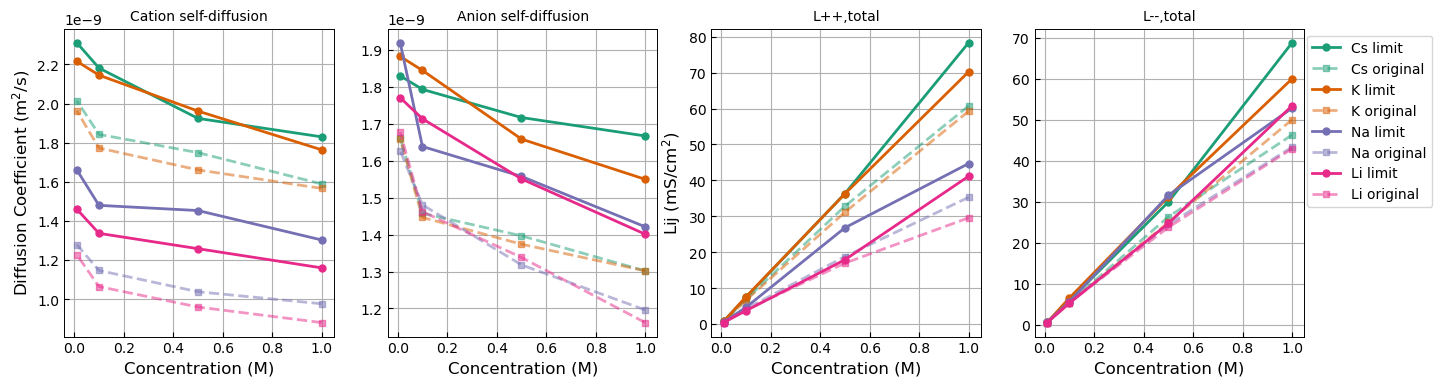

In [40]:
# read in and plot the infinite size limit for diffusion coefficients and add in lij values
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
conc_array = [1.0, 0.5, 0.1, 0.01]
cations = ['Cs', 'K', 'Na', 'Li']

diffusion_limit = np.empty((len(cations), len(concentrations), 2))
lij_limit = np.empty((len(cations), len(concentrations), 3))

diffusion_slopes = np.empty((len(cations), len(concentrations), 2))
lij_slope = np.empty((len(cations), len(concentrations)))

lij_orig = np.empty((len(cations), len(concentrations), 5))
diffusion_orig = np.empty((len(cations), len(concentrations), 2))

colors = plt.get_cmap('Dark2')(range(6))[:2]

print(avg_diff_all)
print(avg_lij_all)
for i, conc in enumerate(concentrations):
    for j, cation in enumerate(cations):
        filepath = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/data/finite-size/{conc}/infinite-size-limit-diffusion.npy'
        diffusion_limit[j,i,:] = np.load(filepath)[j,:]
        print(f'Loaded diffusion limit for {cation} at {conc}: {diffusion_limit[j,i,:]}')

        filepath = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/data/finite-size/{conc}/infinite-size-limit.npy'
        lij_limit[j,i,:] = np.load(filepath)[j,:]

        filepath = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/data/finite-size/{conc}/slopes-diffusion.npy'
        diffusion_slopes[j,i,:] = np.load(filepath)[j,:]

        filepath = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/data/finite-size/{conc}/average-slopes.npy'
        lij_slope[j,i] = np.load(filepath)[j]

        # original (s = 0) values
        lij_orig[j,i,:] = avg_lij_all[j,i,:,0]
        diffusion_orig[j,i,:] = avg_diff_all[j,i,0,:]
        print(avg_diff_all[j,i,0,:])


# plot the infinite size limit for diffusion coefficients
fig, ax = plt.subplots(1, 4, figsize=[16,4])
colors = plt.get_cmap('Dark2')(range(6))[0:]    
print(diffusion_orig)

for i, cation in enumerate(cations):
    ax[0].plot(conc_array, diffusion_limit[i,:,0], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[0].plot(conc_array, diffusion_orig[i,:,0], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)

    ax[2].plot(conc_array, lij_limit[i,:,0], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[2].plot(conc_array, lij_orig[i,:,2], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)

    ax[1].plot(conc_array, diffusion_limit[i,:,1], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[1].plot(conc_array, diffusion_orig[i,:,1], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)

    ax[3].plot(conc_array, lij_limit[i,:,1], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[3].plot(conc_array, lij_orig[i,:,3], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)

ax[0].set_title('Cation self-diffusion')
ax[2].set_title('L++,total')
ax[1].set_title('Anion self-diffusion')
ax[3].set_title('L--,total')

ax[0].set_ylabel(r'Diffusion Coefficient ($m^2/s$)', fontsize=12)
ax[2].set_ylabel(r'Lij ($mS/cm^2$)', fontsize=12)
ax[0].set_xlabel('Concentration (M)', fontsize=12)
ax[1].set_xlabel('Concentration (M)', fontsize=12)
ax[2].set_xlabel('Concentration (M)', fontsize=12)
ax[3].set_xlabel('Concentration (M)', fontsize=12)

ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()
ax[3].legend(frameon=True, fontsize=10, loc='upper right', bbox_to_anchor=(1.5, 1.0))

[[[1.58915136e-09 1.30180618e-09]
  [1.74933429e-09 1.39660942e-09]
  [1.84250507e-09 1.45767804e-09]
  [2.01538481e-09 1.66189727e-09]]

 [[1.56658550e-09 1.30181257e-09]
  [1.66110384e-09 1.37394477e-09]
  [1.77287567e-09 1.44634004e-09]
  [1.96389338e-09 1.65881436e-09]]

 [[9.77324264e-10 1.19595610e-09]
  [1.03881168e-09 1.31803336e-09]
  [1.14745953e-09 1.48050273e-09]
  [1.28008733e-09 1.62677689e-09]]

 [[8.81326432e-10 1.16185569e-09]
  [9.60684084e-10 1.33808910e-09]
  [1.06528070e-09 1.46199889e-09]
  [1.22858775e-09 1.67784278e-09]]]


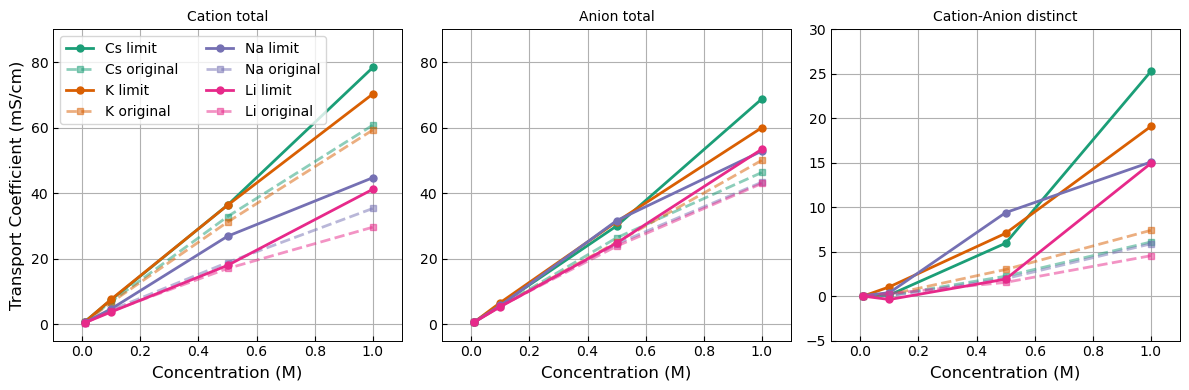

In [44]:
# plot the infinite size limit for lij coefficients 
fig, ax = plt.subplots(1, 3, figsize=[12,4])
colors = plt.get_cmap('Dark2')(range(6))[0:]    
print(diffusion_orig)

for i, cation in enumerate(cations):
    ax[0].plot(conc_array, lij_limit[i,:,0], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[0].plot(conc_array, lij_orig[i,:,2], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)


    ax[1].plot(conc_array, lij_limit[i,:,1], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[1].plot(conc_array, lij_orig[i,:,3], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)

    ax[2].plot(conc_array, lij_limit[i,:,2], linestyle='-', color=colors[i], marker='o', markersize=5, label=f'{cation} limit')
    ax[2].plot(conc_array, lij_orig[i,:,4], color=colors[i], linestyle='--', marker='s', markersize=5, label=f'{cation} original', alpha=0.5)

for i in range(3):
    ax[i].set_title(lij_names[i+2])
    ax[i].set_xlabel('Concentration (M)', fontsize=12)
    ax[i].set_xlim(-0.1, 1.1)

    ax[i].grid()
ax[0].set_ylim(-5, 90)
ax[1].set_ylim(-5, 90)
ax[2].set_ylim(-5, 30)
ax[0].set_ylabel('Transport Coefficient (mS/cm)', fontsize=12)
ax[0].legend(frameon=True, fontsize=10, ncols=2)
plt.tight_layout()

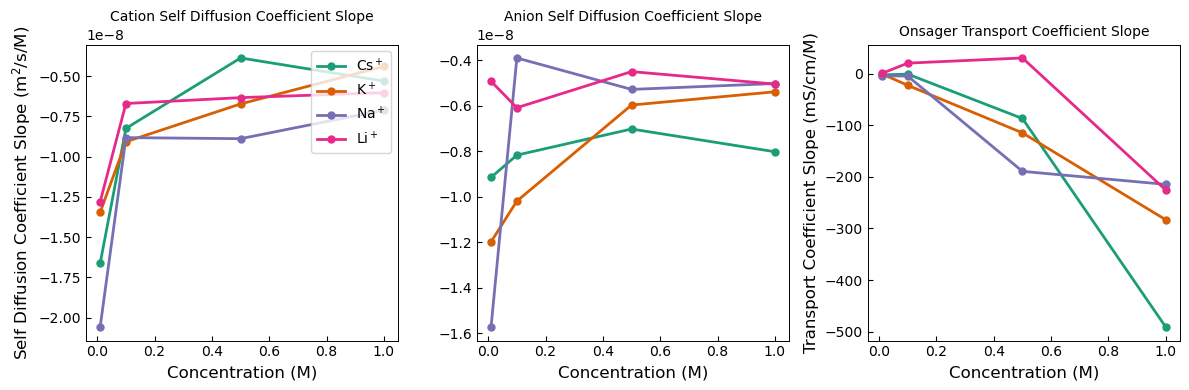

In [45]:
# plot the slopes of the diffusion coefficients and lij values
fig, ax = plt.subplots(1, 3, figsize=[12,4])
for i, cation in enumerate(cations):
    ax[0].plot(conc_array, diffusion_slopes[i,:,0], color=colors[i], marker='o', markersize=5, label=f'{cation}'+r'$^+$')
    ax[1].plot(conc_array, diffusion_slopes[i,:,1], color=colors[i], marker='o', markersize=5, label=f'{cation}')

    ax[0].set_title('Cation Self Diffusion Coefficient Slope')
    ax[1].set_title('Anion Self Diffusion Coefficient Slope')
    ax[0].set_ylabel(r'Self Diffusion Coefficient Slope ($m^2/s/M$)', fontsize=12)
    ax[0].set_xlabel('Concentration (M)', fontsize=12)
    ax[1].set_xlabel('Concentration (M)', fontsize=12)

    ax[2].plot(conc_array, lij_slope[i,:], color=colors[i], marker='o', markersize=5, label=f'{cation}'+r'$^-$')
    ax[2].set_title('Onsager Transport Coefficient Slope')
    ax[2].set_ylabel('Transport Coefficient Slope (mS/cm/M)', fontsize=12)
    ax[2].set_xlabel('Concentration (M)', fontsize=12)
    ax[0].legend(frameon=True, fontsize=10, loc='upper right')
plt.tight_layout()

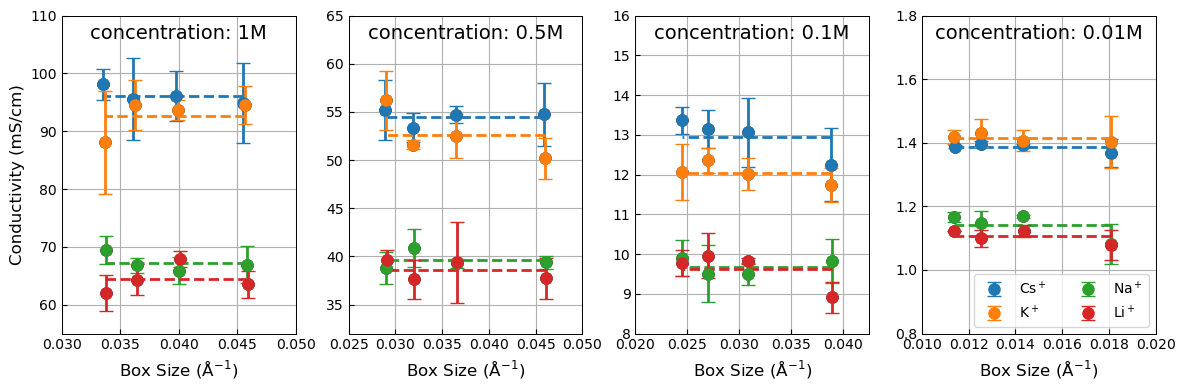

In [69]:
# plot the conductivity vs boxsizes
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
conc_array = [1.0, 0.5, 0.1, 0.01]
cations = ['Cs', 'K', 'Na', 'Li']
colors = plt.get_cmap('tab10')(range(6))
ax_lims = {
    '1M': (0.03, 0.05, 55, 110),
    '0.5M': (0.025, 0.05, 32, 65),
    '0.1M': (0.02, 0.0425, 8, 16),
    '0.01M': (0.01, 0.02, 0.8, 1.8)
}

fig, ax = plt.subplots(1, 4, figsize=[12,4])
for i, cation in enumerate(cations):
    for j, conc in enumerate(concentrations):
        ax[j].scatter(1/box_sizes_all[i,j,:], avg_cond_all[i,j,:], color='k')
        ax[j].errorbar(1/box_sizes_all[i,j,:], avg_cond_all[i,j,:], yerr=std_cond_all[i,j,:], fmt='o', capsize=5, color=colors[i], label=f'{cation}$^+$')  

        ax[j].plot(1/box_sizes_all[i,j,:], np.ones(len(box_sizes_all[i,j,:])) * np.mean(avg_cond_all[i,j,:]), linestyle='--', color=colors[i]) #, label=f'avg cond: {np.mean(avg_cond_all[i,j,:]):.2f} mS/cm')

        ax[j].set_xlabel(r'Box Size ($\AA^{-1}$)', fontsize=12)
        ax[0].set_ylabel('Conductivity (mS/cm)', fontsize=12)
        ax[j].set_title(f'concentration: {conc}', fontsize=14, y=0.9)
        ax[j].set_xlim(ax_lims[conc][:2])
        ax[j].set_ylim(ax_lims[conc][2:])
        if i==0:
            ax[j].grid()
        ax[3].legend(fontsize=10, frameon=True, ncols=2, loc='lower right')
plt.tight_layout()


In [70]:
# compare center of mass vs solvent reference 
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
conc_vals = [1.0, 0.5, 0.1, 0.01]  # molality values for the concentrations
cations = ['Cs', 'K', 'Na', 'Li']
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']

com_lij_all_array = np.empty((len(cations), len(concentrations), len(lij_names)), dtype=object)
com_beta_all_array = np.empty((len(cations), len(concentrations), len(lij_names)), dtype=object)
com_avg_lij_all = np.empty((len(cations), len(concentrations), len(lij_names)))
com_std_lij_all = np.empty((len(cations), len(concentrations), len(lij_names)))

com_cond_all = np.empty((len(cations), len(concentrations)), dtype=object)
com_avg_cond_all = np.empty((len(cations), len(concentrations)))
com_std_cond_all = np.empty((len(cations), len(concentrations)))

com_diff_all = np.empty((len(cations), len(concentrations), 2), dtype=object)
com_avg_diff_all = np.empty((len(cations), len(concentrations), 2))
com_std_diff_all = np.empty((len(cations), len(concentrations), 2))

def cond(lij):
    return lij[2,:] + lij[3,:] - 2 * lij[4,:]

def self_diffusion_coeff(lij, conc):
    c = conc * 1e3  # mol/L to mol/m^3 conversion
    R = 8.314  # J/(mol*K)
    T = 298.15  # K
    return (lij * 0.1 / 96485**2) * (R * T /c) # m^2/s


folder = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/'
figure_folder = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/figures/finite-size/'

for k, cation in enumerate(cations):
    for j, conc in enumerate(concentrations):
            lij_all = np.load(f'{folder}transport-codes-new/with-cation/{cation}/{conc}/total-transport/lij.npy')
            lij_beta_all = np.load(f'{folder}transport-codes-new/with-cation/{cation}/{conc}/total-transport/beta.npy')

            for i in range(len(lij_names)):
                com_lij_all_array[k,j,i] = lij_all[i,:]
                com_beta_all_array[k,j,i] = lij_beta_all[i,:]
            com_avg_lij_all[k,j,:] = np.mean(lij_all, axis=1)
            com_std_lij_all[k,j,:] = np.std(lij_all, axis=1)

            com_cond_all[k,j] = cond(lij_all)
            com_avg_cond_all[k,j] = np.mean(cond(lij_all))
            com_std_cond_all[k,j] = np.std(cond(lij_all))

            com_diff_all[k,j,0] = self_diffusion_coeff(lij_all[0,:], conc_vals[j])
            com_diff_all[k,j,1] = self_diffusion_coeff(lij_all[1,:], conc_vals[j])
            com_avg_diff_all[k,j,0] = np.mean(self_diffusion_coeff(lij_all[0,:], conc_vals[j]))
            com_avg_diff_all[k,j,1] = np.mean(self_diffusion_coeff(lij_all[1,:], conc_vals[j]))
            com_std_diff_all[k,j,0] = np.std(self_diffusion_coeff(lij_all[0,:], conc_vals[j]))
            com_std_diff_all[k,j,1] = np.std(self_diffusion_coeff(lij_all[1,:], conc_vals[j]))


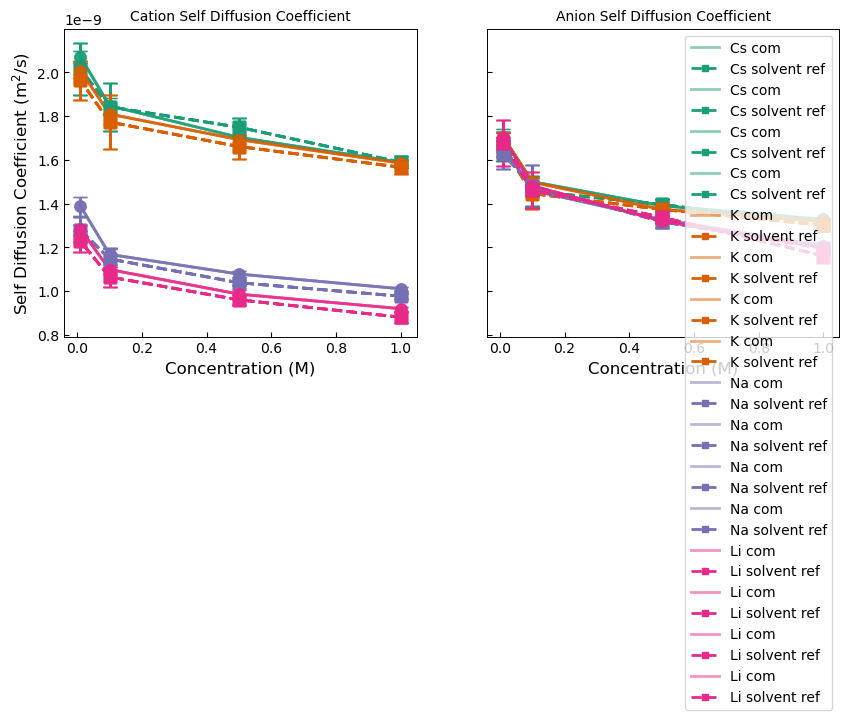

In [75]:
# compare com to solvent reference 
fig, ax = plt.subplots(1, 2, figsize=[10,4], sharey=True, sharex=True)

for i, cat in enumerate(cations):
    for j, conc in enumerate(concentrations):
        ax[0].plot(conc_vals, com_avg_diff_all[i,:,0], color=colors[i], label=f'{cat} com', alpha=0.5)
        ax[0].errorbar(conc_vals, com_avg_diff_all[i,:,0], yerr=com_std_diff_all[i,:,0], fmt='o', capsize=5, color=colors[i], alpha=0.5)

        ax[0].plot(conc_vals, avg_diff_all[i,:,0,0], color=colors[i], marker='s', markersize=5, label=f'{cat} solvent ref', linestyle='--')
        ax[0].errorbar(conc_vals, avg_diff_all[i,:,0,0], yerr=std_diff_all[i,:,0,0], fmt='s', capsize=5, color=colors[i])

        ax[1].plot(conc_vals, com_avg_diff_all[i,:,1], color=colors[i], label=f'{cat} com', alpha=0.5)
        ax[1].errorbar(conc_vals, com_avg_diff_all[i,:,1], yerr=com_std_diff_all[i,:,1], fmt='o', capsize=5, color=colors[i], alpha=0.5)

        ax[1].plot(conc_vals, avg_diff_all[i,:,0,1], color=colors[i], marker='s', markersize=5, label=f'{cat} solvent ref', linestyle='--')
        ax[1].errorbar(conc_vals, avg_diff_all[i,:,0,1], yerr=std_diff_all[i,:,0,1], fmt='s', capsize=5, color=colors[i])

ax[0].set_title('Cation Self Diffusion Coefficient')
ax[1].set_title('Anion Self Diffusion Coefficient')
ax[0].set_ylabel(r'Self Diffusion Coefficient ($m^2/s$)', fontsize=12)
ax[0].set_xlabel('Concentration (M)', fontsize=12)
ax[1].set_xlabel('Concentration (M)', fontsize=12)
ax[1].legend(frameon=True, fontsize=10, loc='upper right')


In [1]:
# plot the lij values
fig, ax = plt.subplots(1, 3, figsize=[12,4], sharey=True, sharex=True)
lij_labels = [r'$L^{++}$', r'$L^{--}$', r'$L^{+-}$']

for i, cat in enumerate(cations):
    for j, conc in enumerate(concentrations):
        ax[0].plot(conc_vals, com_avg_lij_all[i,:,2], color=colors[i], label=f'{cat} com', alpha=0.5)
        ax[0].errorbar(conc_vals, com_avg_lij_all[i,:,2], yerr=com_std_lij_all[i,:,2], fmt='o', capsize=5, color=colors[i], alpha=0.5)

        ax[0].plot(conc_vals, avg_lij_all[i,:,2,0], color=colors[i], marker='s', markersize=5, label=f'{cat} solvent ref', linestyle='--')
        ax[0].errorbar(conc_vals, avg_lij_all[i,:,2,0], yerr=std_lij_all[i,:,2,0], fmt='s', capsize=5, color=colors[i])

        ax[1].plot(conc_vals, com_avg_lij_all[i,:,3], color=colors[i], label=f'{cat} com', alpha=0.5)
        ax[1].errorbar(conc_vals, com_avg_lij_all[i,:,3], yerr=com_std_lij_all[i,:,3], fmt='o', capsize=5, color=colors[i], alpha=0.5)

        ax[1].plot(conc_vals, avg_lij_all[i,:,3,0], color=colors[i], marker='s', markersize=5, label=f'{cat} solvent ref', linestyle='--')
        ax[1].errorbar(conc_vals, avg_lij_all[i,:,3,0], yerr=std_lij_all[i,:,3,0], fmt='s', capsize=5, color=colors[i])

        ax[2].plot(conc_vals, com_avg_lij_all[i,:,4], color=colors[i], label=f'{cat} com', alpha=0.5)
        ax[2].errorbar(conc_vals, com_avg_lij_all[i,:,4], yerr=com_std_lij_all[i,:,4], fmt='o', capsize=5, color=colors[i], alpha=0.5)

        ax[2].plot(conc_vals, avg_lij_all[i,:,4,0], color=colors[i], marker='s', markersize=5, label=f'{cat} solvent ref', linestyle='--')
        ax[2].errorbar(conc_vals, avg_lij_all[i,:,4,0], yerr=std_lij_all[i,:,4,0], fmt='s', capsize=5, color=colors[i])

        

NameError: name 'plt' is not defined